In [1]:
import numpy as np
import numba as nb
import time

Include files that contains all code for simulation

In [2]:
from symbolic.hamiltonian_flow import generate_functions_from_hamiltonian
from integrator.integrate import rk2_ti_step, rk4_ti_step
from plotting.plots  import plot_coordinates, plot_angle, plot_H, plot_power, plot_combine, plot_global_orientation,animate_orientation


# Defining parameters

In [ ]:
def build_params(overrides=None):
    '''
    Builds parameters for simulation
    
    Parameter
    
    overrides:dict
            defines base parameters from which others are computed.
    
    Returns
    
    params:dict
            parameters
    '''

    base = dict(
        rho=2200,
        a=2*80e-9,
        h=2*80e-9,
        T=300,
        lambda_=1064e-9,
        epsilon0=8.85e-12,
        c=3e8,
        P=200e-3,
        a1=1.0,
        psi=0.0,
        Pressure=1000.0,
    )

    if overrides:
        base.update(overrides)

    p = dict(base)

    
    p['V'] = 2 * p['a']**2 * p['h'] / 3
    a_reg = (3 * p['V'] / np.sqrt(2))**(1/3)
    p['r'] = a_reg / 2
    p['m'] = p['rho'] * p['V']
    p['I0'] = (2/5) * p['m'] * p['r']**2

    p['w0'] = p['lambda_'] / 1.3
    p['z_R'] = np.pi * p['w0']**2 / p['lambda_']

    a, h, rho = p['a'], p['h'], p['rho']
    I = 2 * ((a**4 * h)/60 + (a**2 * h**3)/30) * rho
    p['I1'] = I
    p['I2'] = I
    p['I3'] = (a**4 * h)/15

    p['chi1'] = np.sqrt((-p['I1'] + p['I2'] + p['I3']) / p['I0'])
    p['chi2'] = np.sqrt(( p['I1'] - p['I2'] + p['I3']) / p['I0'])
    p['chi3'] = np.sqrt(( p['I1'] + p['I2'] - p['I3']) / p['I0'])

    kb = 1.38e-23
    mg = 29 * 1.66e-27

    vg = np.sqrt((8/np.pi) * kb * p['T'] / mg)
    ng = p['Pressure'] / (kb * p['T'])
    gamma = ((4*np.pi/3) * mg * ng * p['r']**2) * vg * (1 + np.pi/8) / p['m']

    p['dampingT'] = 0.1 * gamma
    p['dampingR'] = 0.1 * gamma
    p['noiseT'] = 2 * kb * p['T'] * p['dampingT'] 
    p['noiseR'] = 2 * kb * p['T'] * p['dampingR'] 

    return p
params = build_params()
params

# Define function that will run the simulation

In [4]:
#simulation function
@nb.njit
def run(x0,h,M,N,fi,gi,noise_all): 
    '''
    Integrate a stochastic dynamical system for multiple trajectories.

    Solves the vector SDE
        dx = f(x) dt + g(x) dW
    using a fixed time step h.

    Parameters:
    
    x0 : ndarray, shape (12, M)
        Initial conditions for M independent trajectories.
    h : float
        Time step size.
    M : int
        Number of trajectories .
    N : int
        Number of time steps.
    fi : callable
        Deterministic drift function f(x).
    gi : callable
        Noise amplitude function g(x).
    noise_all : ndarray, shape (12, M, N)
    
    Pre-generated vector Wiener increments dW for each trajectory and time step .
    Returns
    solution : ndarray, shape (12, M, N)
    Time evolution of all trajectories.
    '''
    solution = np.zeros((12,M,N))
    solution[:,:,0] = x0

    for i in range(1,N):
        solution[:,:,i] = rk4_ti_step(solution[:,:,i-1],0,h,noise_all[:,:,i],fi,gi) #we can also use rk2ti_step
        
    return solution


Generate functions from parameters and Hamiltonian defined in symbolic/hamiltonian_flow.py


In [5]:
H, step , noise , generate_random, f = generate_functions_from_hamiltonian(params)

In [6]:
def simulate_opto(N,M,dt,state0 = [1e-7, 1e-7, 1e-7, 0.1, np.pi/2-0.1, 0.0, 0.0, 0.0, 0.0, 0.0,0.0, 0.0]):
    '''
    This function prepares identical initial conditions for M independent
    trajectories, generates stochastic noise realizations, and integrates
    the equations of motion over N time steps of size dt.    
    
    Parameters
 
    N : int
        Number of time steps.
    M : int
        Number of independent trajectories .
    dt : float
        Time step size.
    state0 : array of length 12
        Initial state shared by all trajectories.
        
    Returns
    
    t : ndarray, shape (N,)
        Time array.
    sol : ndarray, shape (12, M, N)
        Time evolution of all trajectories.
    H_sol : ndarray
        Hamiltonian evaluated along each trajectory.
    '''
    
    x0 = np.zeros((12,M))
    t = np.arange(N) * dt
    for i in range(M):
        x0[:,i] = state0

    noise_all = generate_random(M,N)  
    start = time.time()
    sol = run(x0,dt,M,N,step,noise,noise_all)
    stop = time.time()
    print(stop-start)

    return t,sol,np.array(H(sol))



# Example use


In [7]:
t, sol, energy_val = simulate_opto(2_000_000,10,1*1e-10)

44.69715142250061


Ploted powerspectrum at fig3


0

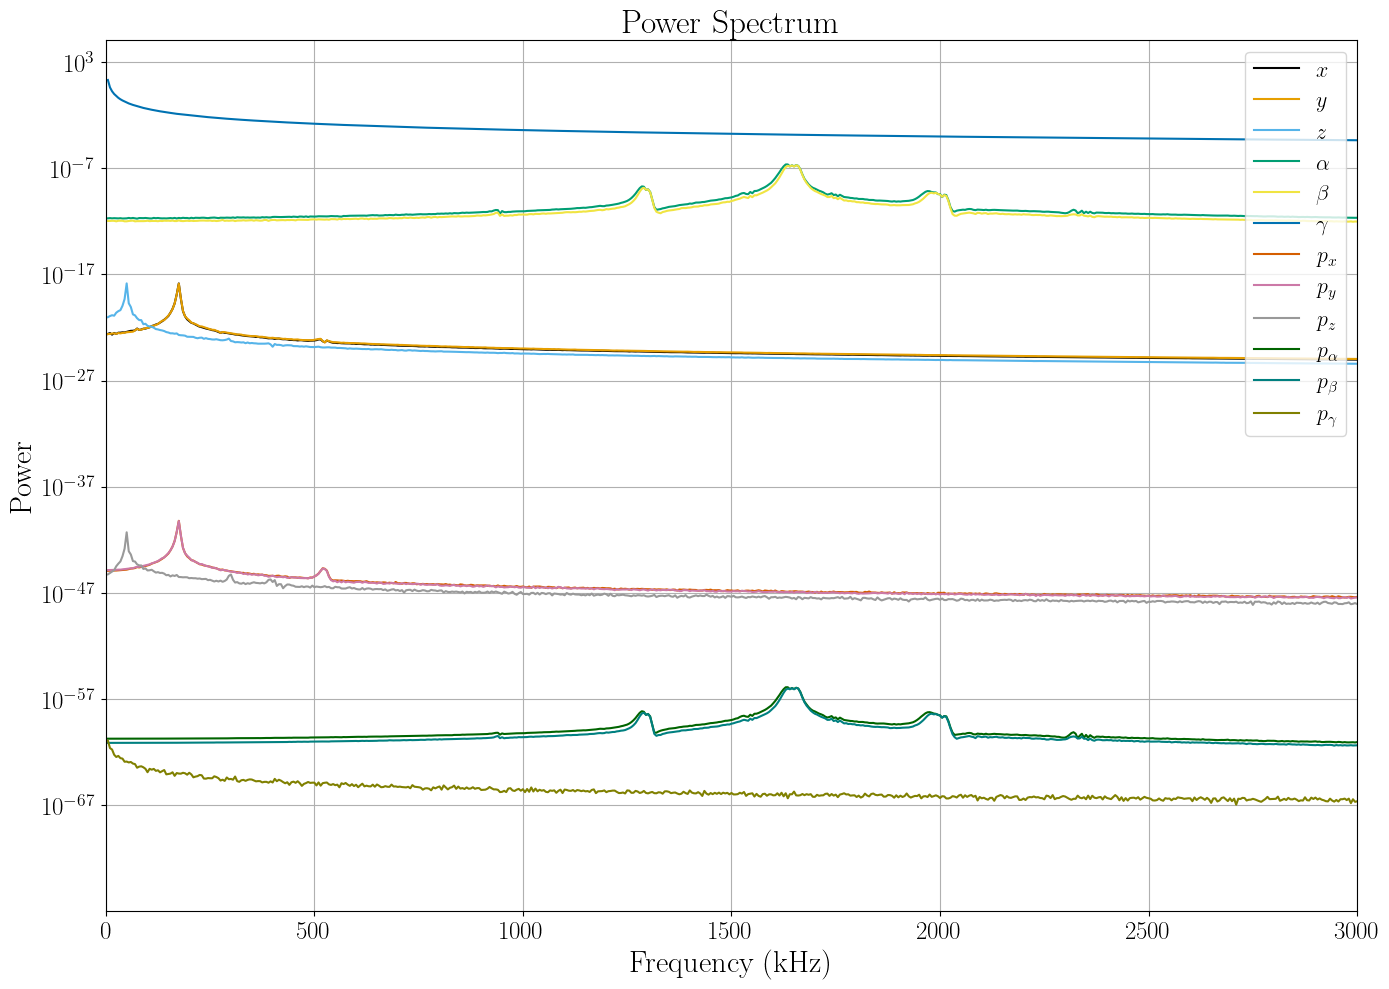

In [8]:
plot_power(1*1e-10,sol)

ploting combined
ploted powerspectrum
ploted signal
saved as figfinal.png


0

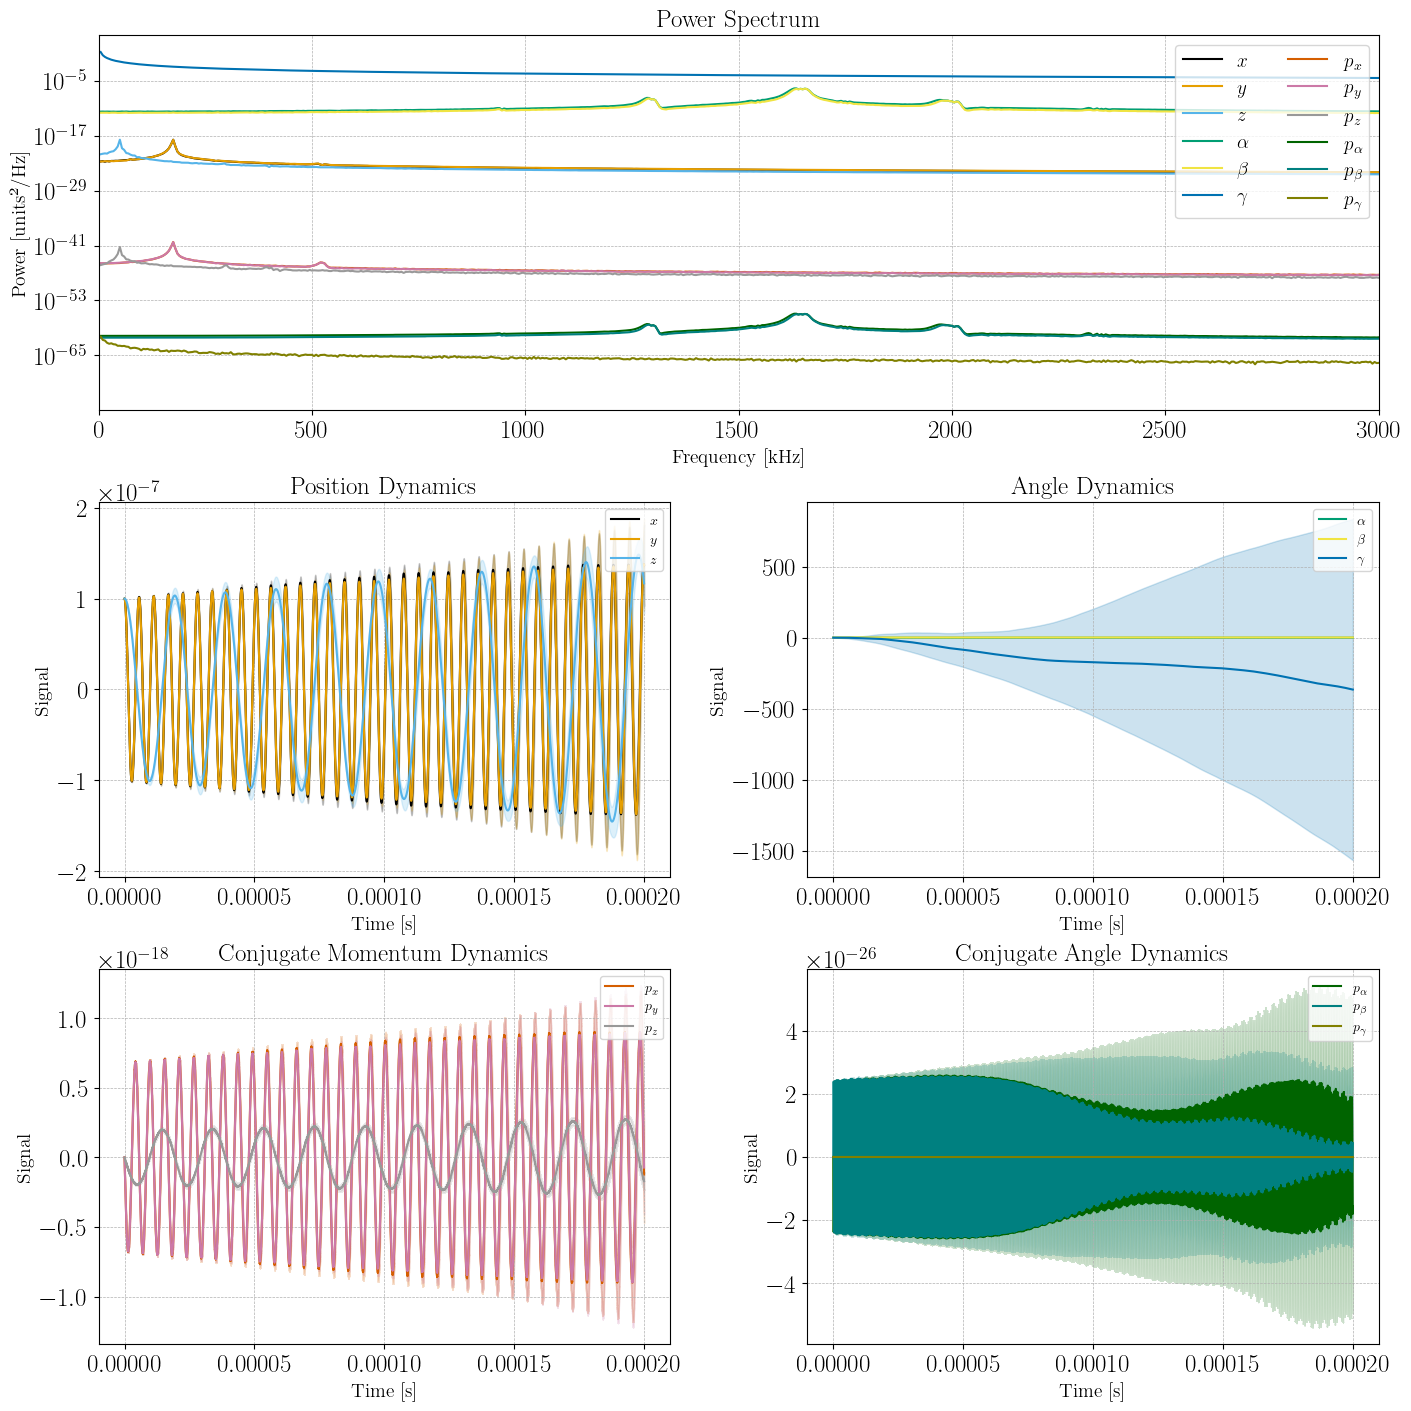

In [9]:
plot_combine(1* 1e-10,t,sol)

Ploted hamiltonian fig2


0

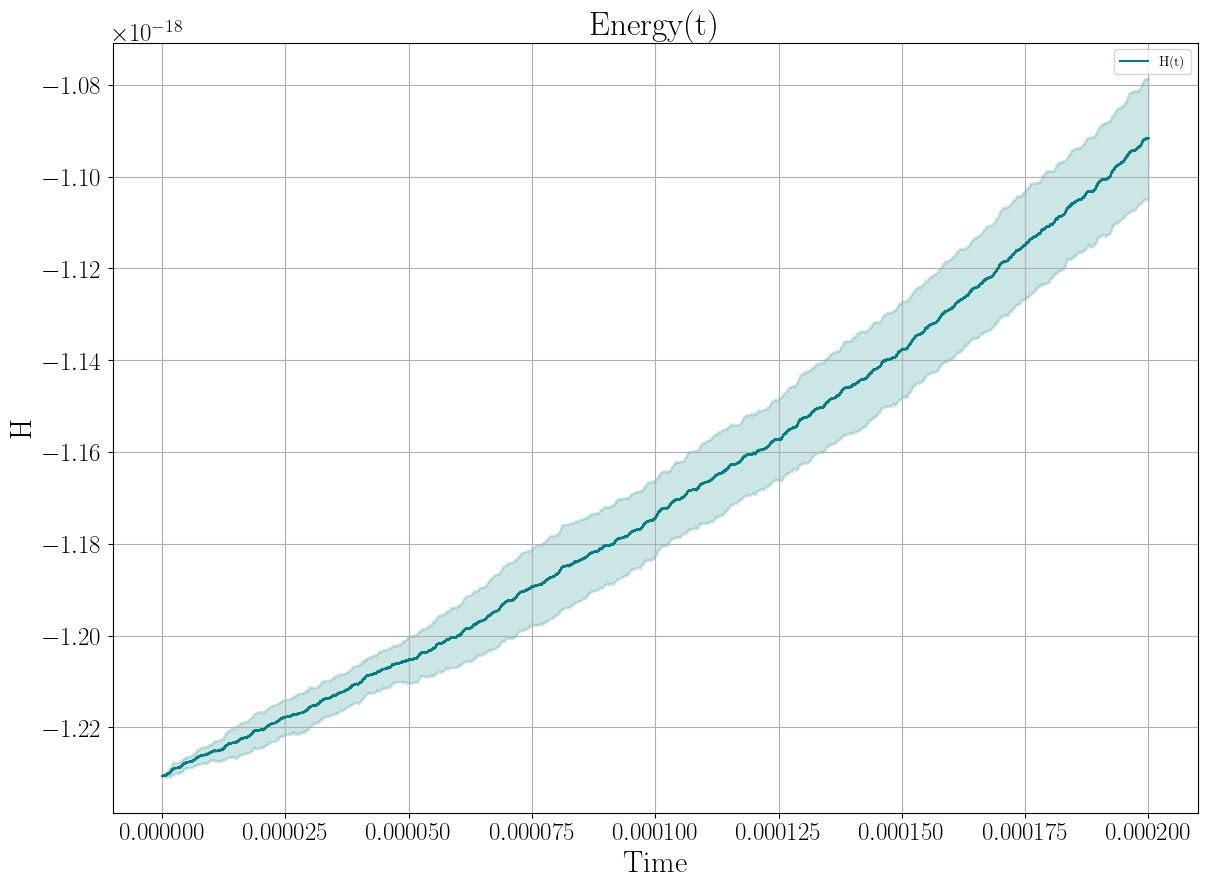

In [10]:
plot_H(t,energy_val)

True


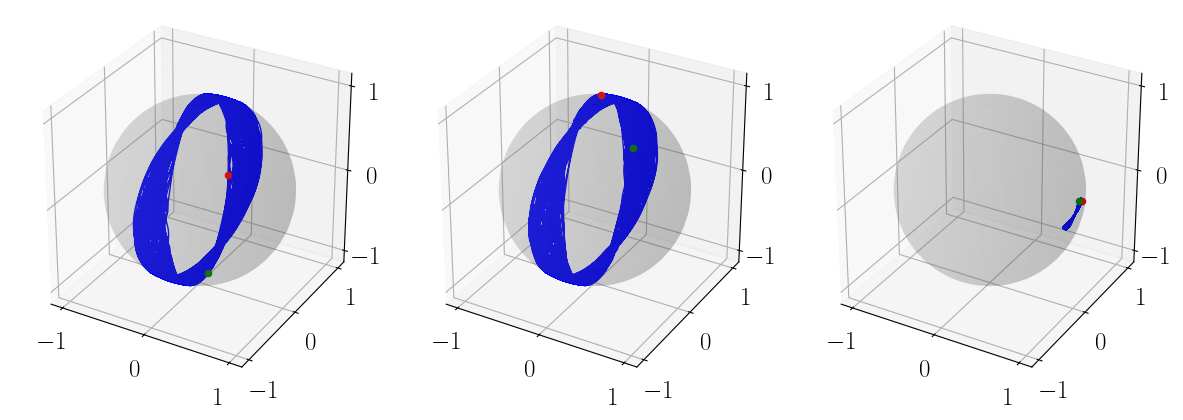

0

In [11]:
plot_global_orientation(sol)

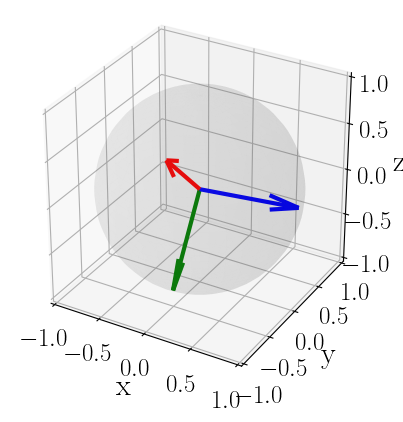

In [18]:
animate_orientation(sol,5 * 10**3,100)